##
 1. Load data (dal CSV / parquet)
 2. Prezzi nel tempo (plot)
3. Distribuzione ritorni (istogrammi, QQ-plot)
 4. Correlation matrix (heatmap)
 5. VIX analysis
6. Rolling volatility
 7. Drawdown
 8. SPX/VIX rolling correlation

Prezzi nel tempo — plot multi-asset con eventi annotati (2008, COVID, 2022 energy crisis)
Distribuzione dei ritorni — istogrammi + QQ-plot vs normale, conferma visiva del Jarque-Bera
Correlation matrix — heatmap, magari separata per sotto-periodi (pre/post 2008)
VIX nel tempo — con soglie e regime flag sovrapposti
Volatility clustering — plot della rolling vol, visivamente si vede già la persistenza
Drawdown chart — per SPX e Brent principalmente
SPX/VIX rolling correlation — per mostrare che cambia nei regimi di stress
Analisi per sotto-periodi — statistiche separate per 2004-2008, 2009-2019, 2020-2022, 2023+

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sns.set_theme(style="whitegrid", palette="muted")

notebook_dir = os.getcwd()
parent_dir = os.path.dirname(notebook_dir)
sys.path.append(parent_dir)
from config_path import cfg_path

# Read processed data from the previously written csv

df = pd.read_parquet(os.path.join(cfg_path.workspace_root, cfg_path.processed_data))
df.head()

,^GSPC,FEZ,CL=F,NG=F,EURUSD=X,USDCHF=X,Brent_EIA,^VIX,^GSPC_log_ret,FEZ_log_ret,...,^GSPC_drawdown,FEZ_drawdown,CL=F_drawdown,NG=F_drawdown,EURUSD=X_drawdown,USDCHF=X_drawdown,Brent_EIA_drawdown,high_vol_regime,bear_market_flag,vol_spike_flag
Date,,,,,,,,,,,,,,,,,,,,,
2004-01-05,1122.219971,17.768866,33.779999,6.827,1.268698,1.2320,32.30,17.49,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,NaN
2004-01-06,1123.670044,17.862984,33.700001,7.082,1.272103,1.2319,31.20,16.73,0.001291,0.005283,...,0.000000,0.000000,-0.002371,0.000000,0.000000,-0.000081,-0.034649,0,0,NaN
2004-01-07,1126.329956,17.615295,33.619999,6.878,1.264095,1.2395,30.99,15.50,0.002364,-0.013963,...,0.000000,-0.013963,-0.004742,-0.029228,-0.006315,0.000000,-0.041169,0,0,NaN
2004-01-08,1131.920044,17.967005,33.980000,7.094,1.277498,1.2266,31.11,15.61,0.004951,0.019769,...,0.000000,0.000000,0.000000,0.000000,0.000000,-0.010462,-0.037463,0,0,NaN
2004-01-09,1121.859985,17.808500,34.310001,7.287,1.285892,1.2212,31.91,16.75,-0.008927,-0.008861,...,-0.008927,-0.008861,0.000000,0.000000,0.000000,-0.014828,-0.013024,0,0,NaN


In [3]:

print(df.shape)
df.describe()

(5446, 61)


,^GSPC,FEZ,CL=F,NG=F,EURUSD=X,USDCHF=X,Brent_EIA,^VIX,^GSPC_log_ret,FEZ_log_ret,...,^GSPC_drawdown,FEZ_drawdown,CL=F_drawdown,NG=F_drawdown,EURUSD=X_drawdown,USDCHF=X_drawdown,Brent_EIA_drawdown,high_vol_regime,bear_market_flag,vol_spike_flag
count,5446.000000,5446.000000,5446.000000,5446.000000,5446.000000,5446.000000,5446.000000,5446.000000,5445.000000,5445.000000,...,5446.000000,5446.000000,5446.000000,5446.000000,5446.000000,5446.000000,5446.000000,5446.000000,5446.000000,5174.000000
mean,2471.827719,30.005463,69.966306,4.367990,1.225246,1.006229,73.930911,18.972591,0.000333,0.000237,...,-0.111945,-0.373064,-0.595285,-0.832560,-0.255113,-0.284724,-0.592003,0.156445,0.209512,0.135099
std,1487.875462,9.754323,21.341922,2.272677,0.127573,0.128582,24.385980,8.527202,0.011943,0.016088,...,0.137373,0.193812,0.278593,0.234732,0.127654,0.119783,0.300204,0.363310,0.406997,0.341862
min,676.530029,12.939043,-37.630001,1.482000,0.959619,0.722800,9.120000,9.140000,-0.127652,-0.133124,...,-0.609717,-0.693269,-0.956126,-0.994491,-0.458849,-0.479035,-0.983682,0.000000,0.000000,0.000000
25%,1288.160004,23.375074,53.330002,2.764250,1.117481,0.916643,55.982500,13.480000,-0.004092,-0.006696,...,-0.180601,-0.513760,-0.811412,-0.968406,-0.363212,-0.366042,-0.859359,0.000000,0.000000,0.000000
50%,1987.355042,28.528316,68.559998,3.667000,1.206891,0.971800,71.185000,16.525001,0.000737,0.000834,...,-0.045937,-0.446412,-0.713647,-0.943161,-0.292859,-0.327420,-0.711058,0.000000,0.000000,0.000000
75%,3263.622559,33.214244,85.547503,5.551750,1.321261,1.061950,90.437500,21.700001,0.005677,0.007962,...,-0.009466,-0.252489,-0.538866,-0.846780,-0.160081,-0.221715,-0.421272,0.000000,0.000000,0.000000
max,6932.049805,64.630753,145.289993,15.378000,1.598798,1.324800,143.950000,82.690002,0.109572,0.161562,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000


## Price evolution over time 
I plot the historical price evolution of all assets in the basket (equity, energy, FX, VIX, Brent).

The goal is to visually identify the main market stress periods (2008 financial crisis, COVID-19 2020,

2022 energy crisis), which should later emerge as distinct regimes in the HMM and change point

detection models.

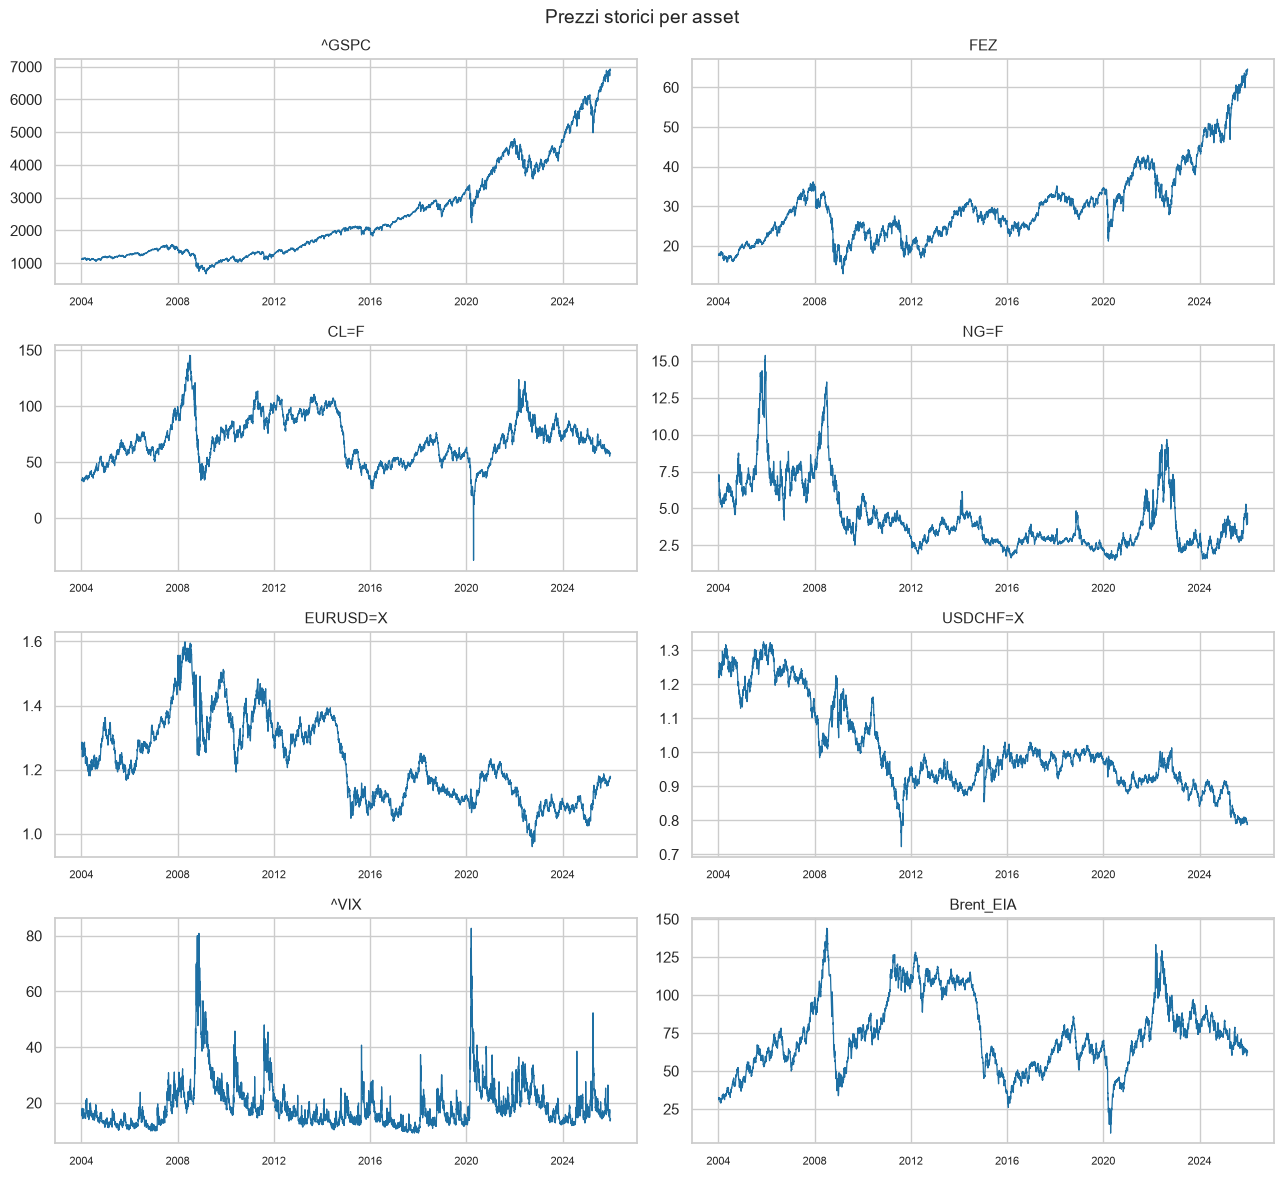

In [4]:
price_cols = ["^GSPC", "FEZ", "CL=F", "NG=F", "EURUSD=X", "USDCHF=X", "^VIX", "Brent_EIA"]

fig, axes = plt.subplots(4, 2, figsize=(13, 12))
axes = axes.flatten()

for i, col in enumerate(price_cols):
    axes[i].plot(df.index, df[col], linewidth=0.9, color="#1D6FA3")
    axes[i].set_title(col, fontsize=11)
    axes[i].tick_params(axis='x', labelsize=8)

fig.suptitle("Prezzi storici per asset", fontsize=14)
plt.tight_layout()
plt.show()

## 2. VIX index over time

The VIX measures the market's expected 30-day volatility, implied by S&P 500 options prices.
It is mean-reverting and spikes sharply during market stress rather than trending persistently
like price levels. Two reference thresholds are shown: 20 (moderate volatility) and 30 (acute stress),
commonly used as informal regime boundaries in practitioner research.

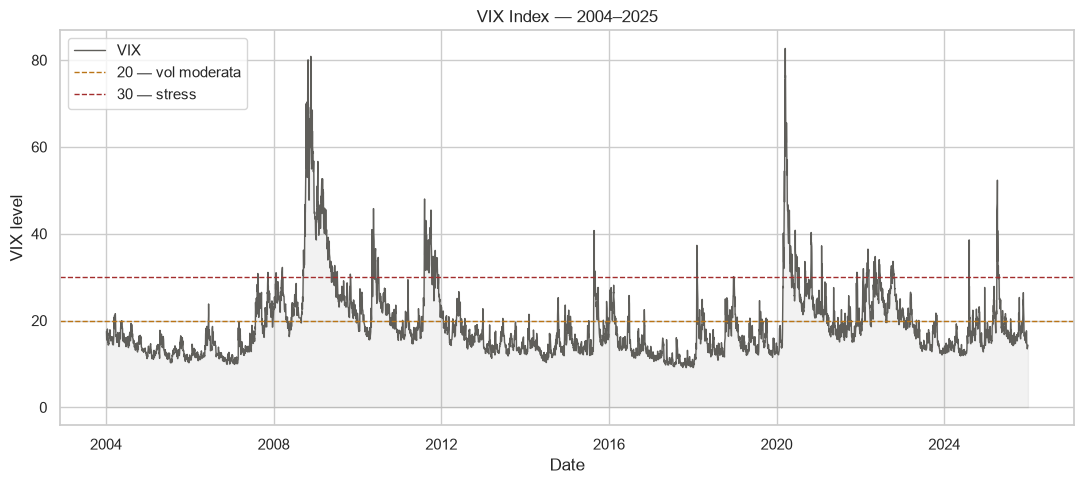

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.fill_between(df.index, df["^VIX"], color="#5F5E5A", alpha=0.08)
ax.plot(df.index, df["^VIX"], color="#5F5E5A", linewidth=1.0, label="VIX")

ax.axhline(20, linestyle="--", color="#BA7517", linewidth=1, label="20 — vol moderata")
ax.axhline(30, linestyle="--", color="#A32D2D", linewidth=1, label="30 — stress")

ax.set_title("VIX Index — 2004–2025")
ax.set_xlabel("Date")
ax.set_ylabel("VIX level")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 3. Log returns distribution

I examine the distributional properties of daily log returns, focusing on the S&P 500 as
the primary benchmark. The computed Jarque-Bera test
indicated departure from normality; here I visualize that departure directly through
a histogram with an overlaid normal density and a QQ-plot.

Jarque-Bera test — ^GSPC_log_ret
Statistic: 41292.75, p-value: 0
Reject normality (non-normal distribution)


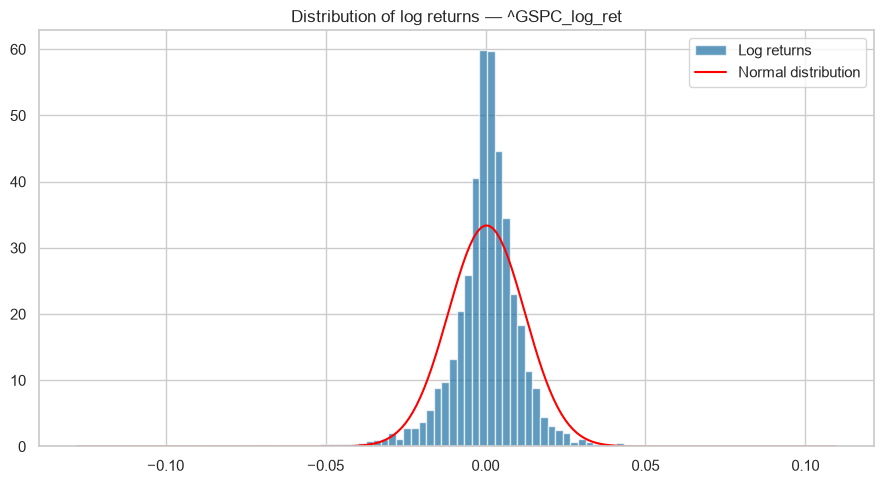

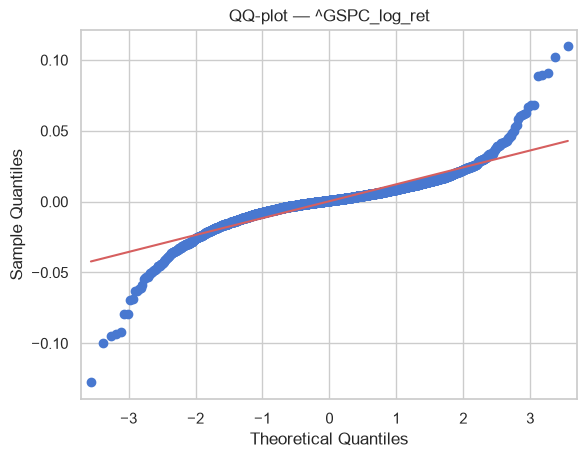

In [6]:
import numpy as np
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt

col = "^GSPC_log_ret"
returns = df[col].dropna()

jb_stat, jb_pval = stats.jarque_bera(returns)
print(f"Jarque-Bera test — {col}")
print(f"Statistic: {jb_stat:.2f}, p-value: {jb_pval:.4g}")
print("Normal" if jb_pval > 0.05 else "Reject normality (non-normal distribution)")

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(returns, bins=100, density=True, color="#1D6FA3", alpha=0.7, label="Log returns")

x_range = np.linspace(returns.min(), returns.max(), 200)
normal_curve = stats.norm.pdf(x_range, returns.mean(), returns.std())
ax.plot(x_range, normal_curve, color="red", linewidth=1.5, label="Normal distribution")

ax.set_title(f"Distribution of log returns — {col}")
ax.legend()
plt.tight_layout()
plt.show()

# QQ-plot for log returns
sm.qqplot(returns, line="s")
plt.title(f"QQ-plot — {col}")
plt.show()

## 5. Correlation matrix

I compute the pairwise correlation matrix of daily log returns across all assets.
This provides a static view of co-movement and helps sanity-check the dataset against
known relationships (e.g. positive correlation between S&P 500 and Euro Stoxx 50).

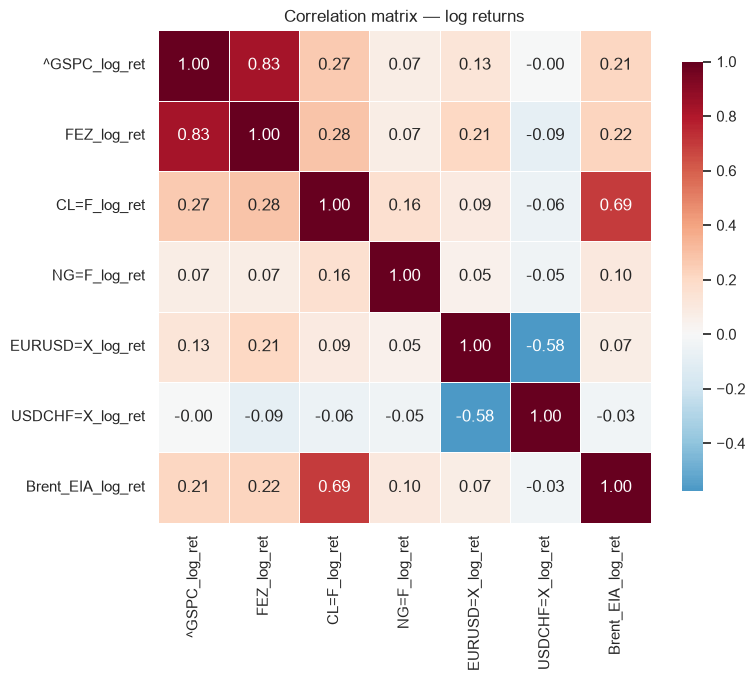

In [7]:
log_ret_cols = [c for c in df.columns if c.endswith("_log_ret")]
corr_matrix = df[log_ret_cols].corr()

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation matrix — log returns")
plt.tight_layout()
plt.show()

## 6. Rolling volatility vs VIX

I plot the 21-day realized volatility of the S&P 500 alongside the VIX index.
Since the VIX is a forward-looking, options-implied measure while realized volatility is
backward-looking, I expect them to move together but not coincide exactly — divergences
between the two are themselves informative about market regime shifts.

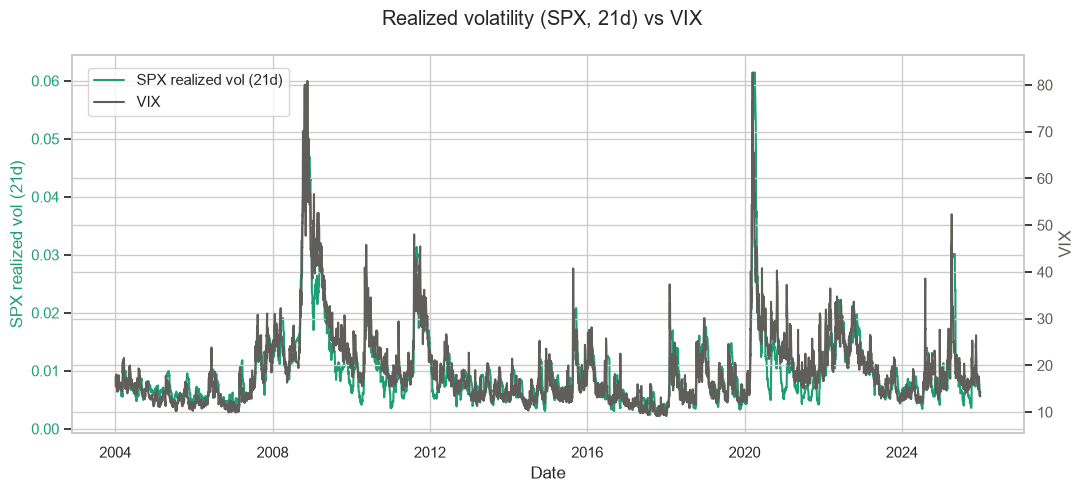

In [8]:
fig, ax1 = plt.subplots(figsize=(11, 5))

ax1.plot(df.index, df["^GSPC_vol_21d"], color="#1D9E75", label="SPX realized vol (21d)")
ax1.set_ylabel("SPX realized vol (21d)", color="#1D9E75")
ax1.tick_params(axis='y', labelcolor="#1D9E75")
ax1.set_xlabel("Date")

ax2 = ax1.twinx()
ax2.plot(df.index, df["^VIX"], color="#5F5E5A", label="VIX")
ax2.set_ylabel("VIX", color="#5F5E5A")
ax2.tick_params(axis='y', labelcolor="#5F5E5A")

fig.suptitle("Realized volatility (SPX, 21d) vs VIX")
fig.legend(loc="upper left", bbox_to_anchor=(0.08, 0.88))
plt.tight_layout()
plt.show()

## 7. Drawdown

I compute the drawdown from peak for the S&P 500, i.e. the percentage decline from the
highest cumulative value reached so far. This highlights both the depth and duration of
major stress periods, complementing the volatility-based view above.

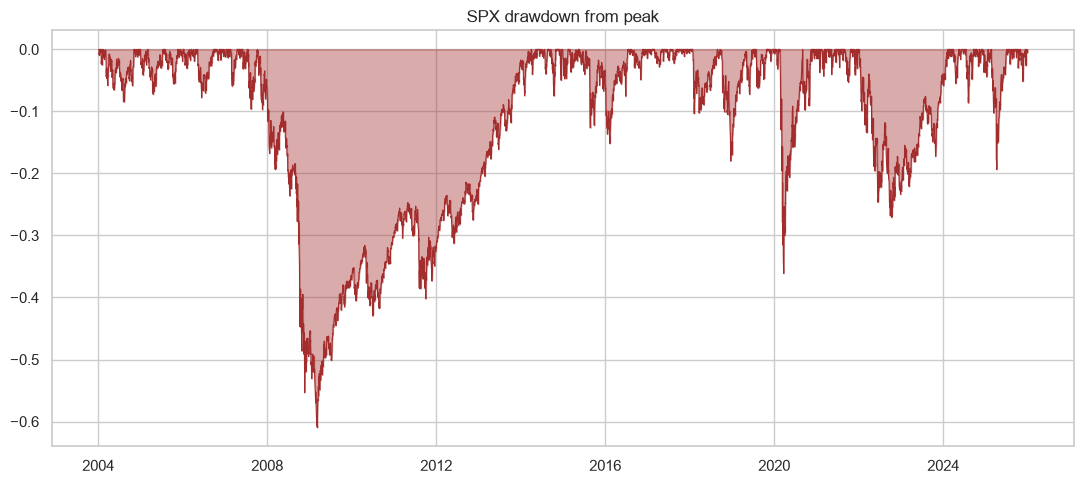

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(df.index, df["^GSPC_drawdown"], color="#A32D2D", alpha=0.4)
ax.plot(df.index, df["^GSPC_drawdown"], color="#A32D2D", linewidth=0.8)
ax.set_title("SPX drawdown from peak")
plt.tight_layout()
plt.show()

## 8. Rolling correlation: S&P 500 vs VIX

I examine the 63-day rolling correlation between S&P 500 and VIX log returns. This
correlation is structurally negative under normal market conditions, but tends to
compress toward zero during periods of acute stress — making it a useful regime
indicator in its own right.

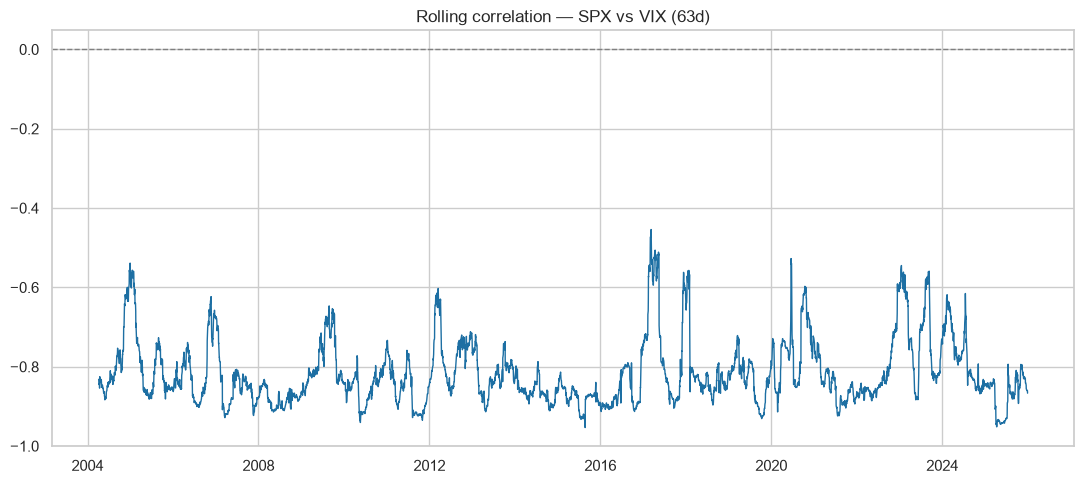

In [10]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(df.index, df["spx_vix_rolling_corr"], color="#1D6FA3", linewidth=1.0)
ax.axhline(0, linestyle="--", color="gray", linewidth=1)
ax.set_title("Rolling correlation — SPX vs VIX (63d)")
plt.tight_layout()
plt.show()

## 9. Sub-period statistics

I split the sample into five sub-periods (pre-GFC, the 2008-2009 financial crisis,
2010-2019, the 2020-2022 COVID/energy crisis window, and 2023-2025) and compute summary
statistics of S&P 500 log returns for each. This gives an empirical, model-free sense of
how many distinct regimes the data might contain, ahead of formal regime detection.

In [11]:
periods = {
    "2004-2007": ("2004-01-01", "2007-12-31"),
    "2008-2009 (GFC)": ("2008-01-01", "2009-12-31"),
    "2010-2019": ("2010-01-01", "2019-12-31"),
    "2020-2022 (COVID+energy)": ("2020-01-01", "2022-12-31"),
    "2023-2025": ("2023-01-01", "2025-12-31"),
}

records = []
for label, (start, end) in periods.items():
    subset = df.loc[start:end, "^GSPC_log_ret"].dropna()
    records.append({
        "period": label,
        "mean_daily_ret": subset.mean(),
        "ann_vol": subset.std() * np.sqrt(252),
        "skew": subset.skew(),
        "kurtosis": subset.kurt()
    })

print(pd.DataFrame(records).set_index("period"))

                          mean_daily_ret   ann_vol      skew   kurtosis
period                                                                 
2004-2007                       0.000272  0.121033 -0.317141   1.807681
2008-2009 (GFC)                -0.000566  0.353882 -0.114471   4.203413
2010-2019                       0.000427  0.148009 -0.551107   4.493974
2020-2022 (COVID+energy)        0.000233  0.257371 -0.755528  10.849529
2023-2025                       0.000794  0.150586  0.332480  14.339260


## 10. Stationarity check (Augmented Dickey-Fuller test)

Most time series models (HMM, GARCH) assume stationary input. I verify empirically what
is normally assumed: price levels should be non-stationary (they follow a random-walk-like
process with trend), while log returns should be stationary. The ADF test formalizes this —
a low p-value rejects the null hypothesis of a unit root, i.e. confirms stationarity.

In [12]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    result = adfuller(series.dropna())
    verdict = "stationary" if result[1] < 0.05 else "non-stationary"
    print(f"{name:25s} ADF stat={result[0]:8.3f}  p-value={result[1]:.4f}  -> {verdict}")

adf_test(df["^GSPC"], "SPX price level")
adf_test(df["^GSPC_log_ret"], "SPX log returns")
adf_test(df["^VIX"], "VIX level")
adf_test(df["Brent_EIA"], "Brent price level")

SPX price level           ADF stat=   2.548  p-value=0.9991  -> non-stationary
SPX log returns           ADF stat= -15.950  p-value=0.0000  -> stationary
VIX level                 ADF stat=  -5.796  p-value=0.0000  -> stationary
Brent price level         ADF stat=  -2.948  p-value=0.0400  -> stationary


## 11. Autocorrelation: returns vs squared returns

Market efficiency implies that raw returns should show little to no autocorrelation —
past returns shouldn't predict future ones. However, squared returns (a proxy for variance)
are expected to show strong, persistent autocorrelation. This is the empirical signature of
volatility clustering: large moves tend to be followed by large moves, regardless of sign.

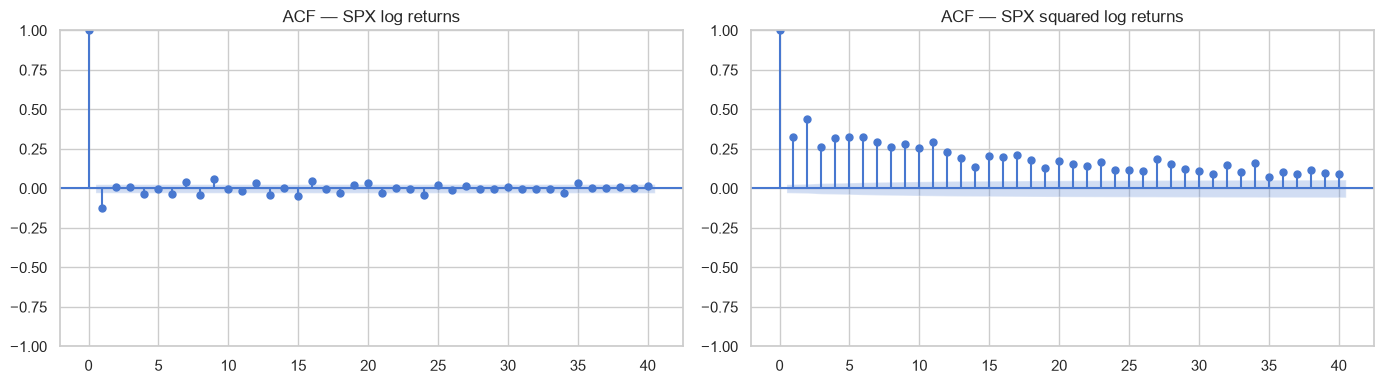

In [13]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df["^GSPC_log_ret"].dropna(), lags=40, ax=axes[0])
axes[0].set_title("ACF — SPX log returns")
plot_acf(df["^GSPC_log_ret"].dropna()**2, lags=40, ax=axes[1])
axes[1].set_title("ACF — SPX squared log returns")
plt.tight_layout()
plt.show()

## 12. Ljung-Box test on squared returns

I formally test what the ACF plot above suggests visually: whether squared returns exhibit
statistically significant autocorrelation at multiple lags. A low p-value confirms the
presence of volatility clustering beyond what could be attributed to random noise.

In [14]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_result = acorr_ljungbox(df["^GSPC_log_ret"].dropna()**2, lags=[5, 10, 20], return_df=True)
print(lb_result)

        lb_stat  lb_pvalue
5   3138.879570        0.0
10  5343.273677        0.0
20  7536.465902        0.0


## 13. ARCH test (conditional heteroskedasticity)

Engle's ARCH test directly examines whether the variance of returns is time-varying and
predictable from its own past — i.e. whether the series exhibits autoregressive conditional
heteroskedasticity. A significant result is the formal statistical justification for moving
to a GARCH-family model rather than assuming constant volatility.

In [15]:
from statsmodels.stats.diagnostic import het_arch

arch_stat, arch_pval, f_stat, f_pval = het_arch(df["^GSPC_log_ret"].dropna())
print(f"ARCH test (LM): stat={arch_stat:.2f}, p-value={arch_pval:.4f}")
print(f"ARCH test (F):  stat={f_stat:.2f}, p-value={f_pval:.4f}")

ARCH test (LM): stat=1543.86, p-value=0.0000
ARCH test (F):  stat=215.20, p-value=0.0000
